In [2]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from torch.utils.data import DataLoader, Dataset


import torch_geometric
import torch_geometric.nn as gnn 
from torch_geometric.data import Data


import os 
import cv2 
import h5py
import numpy as np 
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import KDTree, Delaunay
from tqdm import tqdm

In [3]:
PATH = "Dataset.hdf5"

In [4]:
files = h5py.File(PATH, "r")
xdataset = np.array(files["X_jets"])
m0  = np.array(files["m0"])
pt = np.array(files["pt"])
ydataset = np.array(files["y"])

In [5]:
import random
c = random.randint(0, 100000)

np.array(files["m0"])[c], np.array(files["pt"])[c]

(np.float32(12.533195), np.float32(92.23422))

In [6]:
def standard_scale(data):
    
    # Min-Max Scaling to [0, 1]
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    
    return scaled_data

In [7]:
xdataset[:, :, :, 0] = standard_scale(np.sqrt(np.sqrt(xdataset[:, :, :, 0])))
xdataset[:, :, :, 1] = standard_scale(xdataset[:, :, :, 1])
xdataset[:, :, :, 2] = standard_scale(xdataset[:, :, :, 2])


m0 = standard_scale(m0)
pt = standard_scale(pt)

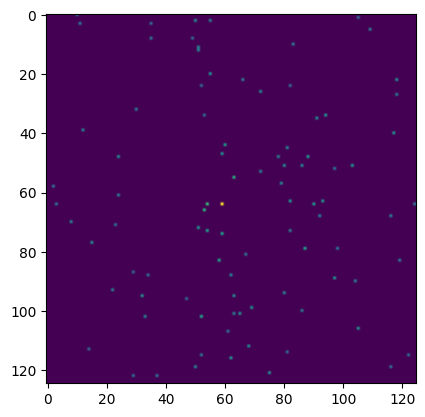

In [8]:
plt.imshow(xdataset[0, :, :, 0])

In [9]:
def extract_points_from_image(image, label, m0, pt):
    threshold = max(0.01, np.mean(image[image > 0]) * 0.1)  # Adaptive thresholding
    points = np.argwhere(image > threshold)
    intensities = image[points[:, 0], points[:, 1]]
    
    return np.column_stack((points, intensities, np.full(len(points), label), 
                            np.full(len(points), m0), np.full(len(points), pt))) if len(points) > 0 else np.empty((0, 6))

def compute_track_weights(track_img, all_nodes, G):
    track_points = np.argwhere(track_img > 0)
    if track_points.size == 0:
        return
    
    track_tree = KDTree(track_points)
    track_intensities = track_img[track_points[:, 0], track_points[:, 1]]
    
    for i, j in G.edges():
        center = (all_nodes[i, :2] + all_nodes[j, :2]) / 2.0
        distances, idxs = track_tree.query(center, k=len(track_points))
        weights = track_intensities[idxs] / (1 + (distances/60.0)**2)  # Inverse-square weighting
        G[i][j]['weight'] = max(np.sum(weights), 1e-6)

def point_cloud_to_graph(ecal_points, hcal_points, track_img):
    if len(ecal_points) == 0 and len(hcal_points) == 0:
        return nx.Graph()
    
    all_nodes = np.vstack([ecal_points, hcal_points]) if ecal_points.size and hcal_points.size else ecal_points if ecal_points.size else hcal_points
    all_nodes[:, 2] /= np.max(all_nodes[:, 2]) if np.max(all_nodes[:, 2]) > 0 else 1
    
    G = nx.Graph()
    node_attrs = {i: {'intensity': p[2], 'x': (p[0]/62.5) - 1, 'y': (p[1]/62.5) -  1, 
                  'is_ecal': (p[3] == -1), 'is_hcal': (p[3] == 1), 'm0': p[4], 'pt': p[5]} 
              for i, p in enumerate(all_nodes)}

    G.add_nodes_from(node_attrs.items())
    
    if len(all_nodes) > 2:
        delaunay = Delaunay(all_nodes[:, :2])
        for simplex in delaunay.simplices:
            for i, j in zip(simplex, np.roll(simplex, -1)):
                distance = np.linalg.norm(all_nodes[i, :2] - all_nodes[j, :2])
                weight = np.exp(-distance / 5)
                G.add_edge(i, j, weight=weight)
    
    compute_track_weights(track_img, all_nodes, G)
    
    return G

def convert_to_pyg_graph(graph):
    if len(graph) == 0:
        return None
    
    node_features = [[attrs['intensity'], attrs['x'], attrs['y'], attrs['is_ecal'], attrs['is_hcal'], attrs['m0'], attrs['pt']] for _, attrs in graph.nodes(data=True)]
    node_mapping = {node: i for i, node in enumerate(graph.nodes())}
    
    edge_index = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in graph.edges()], dtype=torch.long).t().contiguous()
    edge_weights = torch.tensor([graph[u][v]['weight'] for u, v in graph.edges()], dtype=torch.float)
    
    return Data(x=torch.tensor(node_features, dtype=torch.float), edge_index=edge_index, edge_attr=edge_weights)

def process_dataset(xdataset, ydataset, m0_values, pt_values):
    graph_dataset = []
    
    for idx, (xdata, ydata) in enumerate(tqdm(zip(xdataset, ydataset), desc="Processing images")):
        ecal_points = extract_points_from_image(xdata[:, :, 0], -1, m0_values[idx], pt_values[idx])
        hcal_points = extract_points_from_image(xdata[:, :, 1], 1, m0_values[idx], pt_values[idx])
        
        graph = point_cloud_to_graph(ecal_points, hcal_points, xdata[:, :, 2])
        if len(graph) == 0:
            continue
        
        pyg_graph = convert_to_pyg_graph(graph)
        if pyg_graph is None:
            continue
        
        pyg_graph.y = torch.tensor(ydata.astype(int), dtype=torch.long)
        graph_dataset.append(pyg_graph)
    
    return graph_dataset


In [10]:
xyz = 50000
dataset = process_dataset(xdataset[:xyz], ydataset[:xyz], m0[:xyz], pt[:xyz])

Processing images: 50000it [09:42, 85.90it/s] 


In [11]:
import open3d as o3d
import numpy as np

import plotly.graph_objects as go
import networkx as nx
import numpy as np

def visualize_graph_plotly(graph):
    # Extract node positions and attributes
    node_x = []
    node_y = []
    node_z = []
    node_colors = []
    node_sizes = []

    for i, data in graph.nodes(data=True):
        x = data['x']
        y = data['y']
        z = i  # using index as z
        intensity = data['intensity']
        mag = data['mag']

        node_x.append(x)
        node_y.append(y)
        node_z.append(z)
        node_colors.append(mag)
        node_sizes.append(intensity * 10)

    # Edge coordinates
    edge_x = []
    edge_y = []
    edge_z = []

    for u, v in graph.edges():
        edge_x += [graph.nodes[u]['x'], graph.nodes[v]['x'], None]
        edge_y += [graph.nodes[u]['y'], graph.nodes[v]['y'], None]
        edge_z += [u, v, None]  # z = index

    # Create edge trace
    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        line=dict(width=2, color='black'),
        hoverinfo='none',
        mode='lines'
    )

    # Create node trace
    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode='markers',
        marker=dict(
            size=node_sizes,
            color=node_colors,
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Magnitude')
        ),
        hoverinfo='text',
        text=[f"Node {i}, Intensity: {graph.nodes[i]['intensity']:.2f}, Mag: {graph.nodes[i]['mag']:.2f}" for i in graph.nodes]
    )

    # Create the figure
    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        title="Graph Visualization in 3D",
        width=800, height=600,
        scene=dict(
            xaxis=dict(title='X'),
            yaxis=dict(title='Y'),
            zaxis=dict(title='Z (Node index)')
        ),
        showlegend=False
    )
    fig.show()



def pyg_to_nx(pyg_graph):
    """Converts a PyTorch Geometric Data object to a NetworkX graph."""
    G = nx.Graph()
    
    # Add nodes with their attributes
    for i in range(pyg_graph.num_nodes):
        intensity = pyg_graph.x[i][0].item()  # Assuming intensity is the first feature
        mag = pyg_graph.x[i][1].item()         # Assuming mag is the second feature
        x = int(pyg_graph.x[i][2].item()  *125 )        # Assuming x coordinate is the third feature
        y = int(pyg_graph.x[i][3].item() *125  )   # Assuming y coordinate is the fourth feature
        G.add_node(i, intensity=intensity, mag=mag, x=x, y=y)

    # Add edges with weights
    for edge_index in pyg_graph.edge_index.t().tolist():
        i, j = edge_index  # i and j are already integers
        edge_idx = (pyg_graph.edge_index[0] == i) & (pyg_graph.edge_index[1] == j)
        weight = pyg_graph.edge_attr[edge_idx.nonzero(as_tuple=True)[0][0]].item()  # Get the weight for the edge
        G.add_edge(i, j, weight=weight)  # Use i and j directly

    return G

if dataset:
    nx_graph = pyg_to_nx(dataset[0])
    visualize_graph_plotly(nx_graph)


In [12]:
from sklearn.model_selection import train_test_split

# Assuming `graph_dataset` is your list of Data objects
train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train: {len(train_data)}, Validation: {len(val_data)}, Test: {len(test_data)}")


Train: 30000, Validation: 10000, Test: 10000


In [13]:
from torch_geometric.loader import DataLoader

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GAT, GraphConv, SAGEConv,  SAGPooling, GraphNorm, global_mean_pool
from torch_geometric.nn.conv import GINEConv

class GNNBlock(nn.Module):
    def __init__(self, hidden_dim, input_dim=None):
        super(GNNBlock, self).__init__()
        input_dim = hidden_dim if input_dim is None else input_dim
        # GAT Layers
        self.gat1 = GAT(input_dim, hidden_dim * 2, num_layers=2)
        self.nor1 = GraphNorm(hidden_dim * 2)
        self.gat2 = GAT(hidden_dim * 2, hidden_dim * 2, num_layers=2)

        # GraphSAGE Layers
        self.sage1 = SAGEConv(input_dim, hidden_dim * 2)
        self.nor2 = GraphNorm(hidden_dim * 2)
        self.sage2 = SAGEConv(hidden_dim * 2, hidden_dim * 2)

        # GraphConv Layers
        self.graphconv1 = GraphConv(input_dim, hidden_dim * 2)
        self.nor3 = GraphNorm(hidden_dim * 2)
        self.graphconv2 = GraphConv(hidden_dim * 2, hidden_dim * 2)

        self.gine1 = GINEConv(nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim*2)), edge_dim=1)
        self.nor4 = GraphNorm(hidden_dim * 2)
        self.gine2 = GINEConv(nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim*2)), edge_dim=1)

        self.norm1 = GraphNorm(hidden_dim * 8 + input_dim)
        self.norm2 = GraphNorm(hidden_dim * 2)

        self.final = GAT(hidden_dim * 8 + input_dim, hidden_dim * 2, num_layers=2)
        self.residual = GraphConv(input_dim, hidden_dim * 2)

        # **Weighted Graph Pooling (SAGPooling)**
        self.pool1 = SAGPooling(hidden_dim * 2, ratio=0.5)  # Retains 25% of nodes

    def forward(self, x, edge_index, batch, edge_weight=None):
        dense = x
        residual = self.residual(x, edge_index, edge_weight)
        # GAT Branch
        gat_out = F.silu(self.nor1(self.gat1(x, edge_index, edge_weight)))
        gat_out = self.gat2(gat_out, edge_index, edge_weight)

        # GraphSAGE Branch
        sage_out = F.silu(self.nor2(self.sage1(x, edge_index)))
        sage_out = self.sage2(sage_out, edge_index)

        gine_out = F.silu(self.nor2(self.gine1(x, edge_index, edge_weight.reshape(-1, 1))))
        gine_out = self.gine2(gine_out, edge_index, edge_weight.reshape(-1, 1))

        # GraphConv Branch
        graphconv_out = F.silu(self.nor3(self.graphconv1(x, edge_index, edge_weight)))
        graphconv_out = self.graphconv2(graphconv_out, edge_index, edge_weight)

        # print(gine_out.shape, sage_out.shape, graphconv_out.shape, dense.shape, gat_out.shape)

        # **Concatenate multi-path features**
        x = F.silu(self.norm1(torch.cat([gat_out, sage_out, graphconv_out, gine_out, dense], dim=1)))

        x = F.silu(self.norm2(self.final(x, edge_index, edge_weight) + residual))
        
        # **Apply weighted pooling**
        # x, edge_index, edge_weight, batch, _, _ = self.pool1(x, edge_index, edge_weight, batch)

        return x, edge_index, edge_weight, batch


class GNNModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=24, output_dim=256):
        super(GNNModel, self).__init__()
        self.graph1 = GNNBlock(hidden_dim, input_dim)
        self.graph2 = GNNBlock(hidden_dim * 2)
        self.graph3 = GNNBlock(hidden_dim * 4)


        self.mlp = nn.Linear(hidden_dim * 8, output_dim)
        self.final_fc = nn.Linear(output_dim, 1)

        self.drop = nn.Dropout(0.0)

    def forward(self, data):
        x, e, b = data.x, data.edge_index, data.batch
        edge_weight = data.edge_attr if hasattr(data, 'edge_attr') else None  # Get edge weights if available

        # Pass through GNN blocks
        x, e, edge_weight, b = self.graph1(x, e, b, edge_weight)
        x, e, edge_weight, b = self.graph2(x, e, b, edge_weight)
        x, e, edge_weight, b = self.graph3(x, e, b, edge_weight)

        x = global_mean_pool(x, b)

        # Fully connected layers
        x = F.silu(self.mlp(self.drop(x)))
        return torch.sigmoid(self.final_fc(self.drop(x)))

In [15]:
c=0
for xdata in train_data:
    if xdata.y == 1:
        c = c+1

In [16]:
len(train_data)

30000

In [17]:
def l2_regularization(model, weight_decay=1e-6, bias_decay=1e-8):
    weight_decay_loss = 0
    bias_decay_loss = 0
    for name, param in model.named_parameters():
        if 'weight' in name:
            weight_decay_loss += torch.norm(param, p=2)  # L2 norm for weights
        elif 'bias' in name:
            bias_decay_loss += torch.norm(param, p=1)  # L2 norm for biases
    return weight_decay * weight_decay_loss + bias_decay * bias_decay_loss


In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau


device = torch.device("cpu" if torch.backends.mps.is_available() else "cpu")
model = GNNModel(input_dim=7, hidden_dim=16, output_dim=32).to(device)  # Output dim = 1 for binary classification

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)  # Reduce LR if no improvement for 5 epochs
loss_fn = nn.BCELoss()

def train():
    model.train()
    for epoch in range(100):
        total_loss = 0
        correct = 0
        total = 0
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for data in train_loader_tqdm:
            data = data.to(device)
            optimizer.zero_grad()
            
            output = model(data).squeeze()

            target = torch.tensor(data.y, dtype=torch.float, device=device)
            loss = loss_fn(output, target)


            regularization_loss = l2_regularization(model)
            loss = loss + regularization_loss  # Total loss = original loss + regularization
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = (output > 0.5).float()
            correct += (pred == target).sum().item()
            total += len(target)

            train_loader_tqdm.set_postfix(loss=total_loss / (total + 1), acc=correct / (total + 1))

        val_loss = validate()  # Get validation loss for scheduler
        scheduler.step(val_loss)  # Adjust LR based on validation loss

        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}, Accuracy: {correct / total:.4f}, LR: {optimizer.param_groups[0]['lr']}")


def validate():
    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc="Validation")
        for data in val_loader_tqdm:
            data = data.to(device)
            output = model(data).squeeze()

            target = torch.tensor(data.y, dtype=torch.float, device=device)

            loss = loss_fn(output, target)
            val_loss += loss.item()

            pred = (output > 0.5).float()
            correct += (pred == target).sum().item()
            total += len(target)

        print(f"Validation Loss: {val_loss / len(val_loader):.4f}, Accuracy: {correct / total:.4f}")
    return val_loss

train()


/Users/macbook/Desktop/अनुसन्धानम् च विकासः/GSOC2025_GENIE/graph/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning:

The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.

Epoch 1:   0%|          | 0/938 [00:00<?, ?it/s]/var/folders/js/4dgw38357d1_69bd7w31mtsm0000gn/T/ipykernel_15297/3778273543.py:28: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

Validation:   0%|          | 0/313 [00:00<?, ?it/s]/var/folders/js/4dgw38357d1_69bd7w31mtsm0000gn/T/ipykernel_15297/3778273543.py:62: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

Validation: 100%|██████████| 313/313 [00:23<00:00, 13.26it/s]


Validation Loss: 0.5907, Accuracy: 0.6948
Epoch 1, Loss: 0.6073, Accuracy: 0.6737, LR: 0.0001


Epoch 2:  45%|████▍     | 420/938 [01:09<01:25,  6.05it/s, acc=0.696, loss=0.0183]


KeyboardInterrupt: 